# Processing Inhibitor Data

____

In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [ ]:
# Loading data
        #RMS External Drive Location:    'E:\Co-translational folding (CoF) paper\Fig 4_Fast_Har analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 4\Fig 4_Harringtonine analysis_GFPFast'


# ── Data Path ─────────────────────────────────────────────
# data_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Gui RMS Analyses' / 'Har' #Onedrive
data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 3_Har/non pb')
 
# elongation rates
def elongation_rates (gene_length,dwell_time ):
    ke = gene_length/ dwell_time
    return np.round(ke,3)

# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 4)
ylims = (-0.1, 1.3)
xlims = (-5, 30.5)                              # limits needs to be set to include more than the fit_end_idx frames for the x-axis
fit_start_idx=inhibitor_frame_index          # int – fit range start (default: inh frame)
fit_end_idx=10                               # int – fit range end (default: last frame) for linear use ~15
results_folder = Path('E:/Co-translational folding (CoF) paper/Fig 3_Har graphs/non pb')  # Set to a Path to save plots


## HA Channel (pRS027; 4xGFPfast)
___

### pRS027_HA_fit (combined dishes)

── Linear Fit ──
  a (slope): -0.1330
  b (intercept): 0.9915
  Iss (baseline): 0.2260
  a_err: 0.0043
  b_err: 0.0156
  t½:      2.88 min
  τ_runoff (2×t½): 5.76 min
  χ²_red:  1.6513  (dof=5)


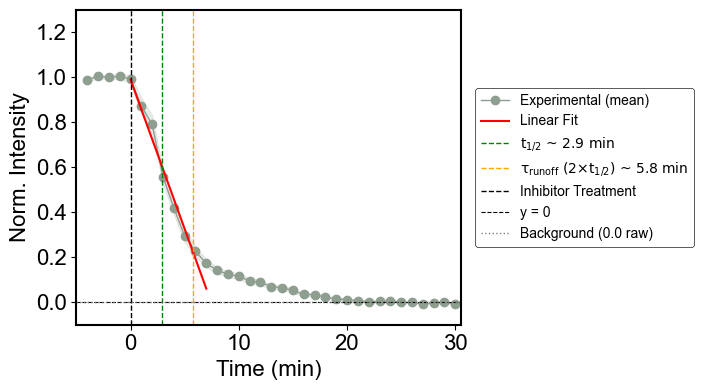

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [3]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_HA_fit'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                # np.ndarray – time array
    intensities_pRS027_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS027_HA, # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='linear',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,               # subtract background & rescale to 0-1
    background_frames=10,                           # use last 10 frames within xlims window
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors='#8E9E8F',
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])


### pRS027 Dish 1

── Linear Fit ──
  a (slope): -0.1250
  b (intercept): 0.9906
  Iss (baseline): 0.2536
  a_err: 0.0064
  b_err: 0.0201
  t½:      2.95 min
  τ_runoff (2×t½): 5.90 min
  χ²_red:  0.7195  (dof=5)


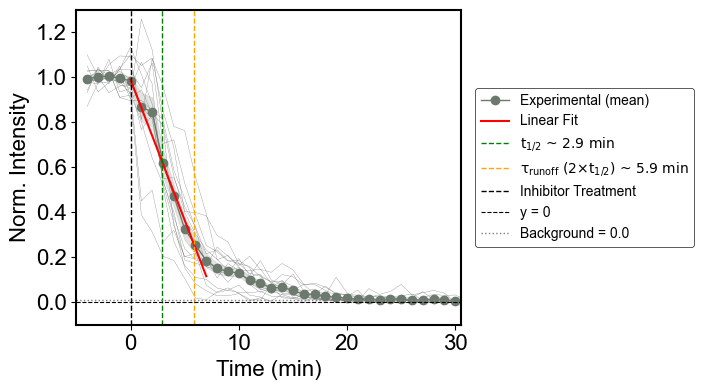

responding_indices_pRS027_Dish1_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
number of responding trajectories for pRS027_Dish1_HA: 13


In [4]:
substring_in_data_dir = 'pRS027_Dish1'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_Dish1_HA'

responding_indices_pRS027_Dish1_HA, frames_pRS027_Dish1_HA, intensities_pRS027_Dish1_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_Dish1_HA, intensities_pRS027_Dish1_HA, inhibitor_frame_index,
    plot_name=plot_name,
    fit_model='linear',
     fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
     fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
     show_fit=True,                                   # bool – overlay fitted curve
     show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
     runoff_fraction=0.90,                            # float – threshold for run-off (0.95 = 95%)
     colors="#6C796D",
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
)

print("responding_indices_pRS027_Dish1_HA:", responding_indices_pRS027_Dish1_HA)
print("number of responding trajectories for pRS027_Dish1_HA:", len(responding_indices_pRS027_Dish1_HA))

### pRS027 Dish 2

── Linear Fit ──
  a (slope): -0.1321
  b (intercept): 0.9722
  Iss (baseline): 0.2300
  a_err: 0.0050
  b_err: 0.0209
  t½:      2.81 min
  τ_runoff (2×t½): 5.62 min
  χ²_red:  3.4336  (dof=5)


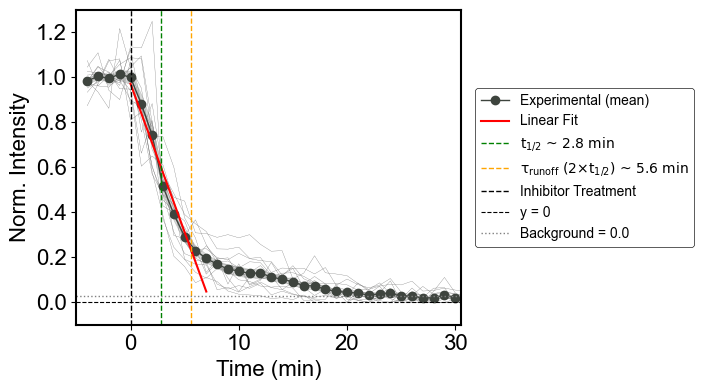

responding_indices_pRS027_Dish2_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
number of responding trajectories for pRS027_Dish2_HA: 13


In [5]:
substring_in_data_dir = 'pRS027_Dish2'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_Dish2_HA'

responding_indices_pRS027_Dish2_HA, frames_pRS027_Dish2_HA, intensities_pRS027_Dish2_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_Dish2_HA, intensities_pRS027_Dish2_HA, inhibitor_frame_index,
     plot_name=plot_name,
    fit_model='linear',
     fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
     fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
     show_fit=True,                                   # bool – overlay fitted curve
     show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
     runoff_fraction=0.90,                            # float – threshold for run-off (0.95 = 95%)
     colors='#3E443E',
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
)

print("responding_indices_pRS027_Dish2_HA:", responding_indices_pRS027_Dish2_HA)
print("number of responding trajectories for pRS027_Dish2_HA:", len(responding_indices_pRS027_Dish2_HA))

## pRS027 combined data only

fit_inhibitor_model: unknown model "none". Choose from: linear, exponential, heaviside.


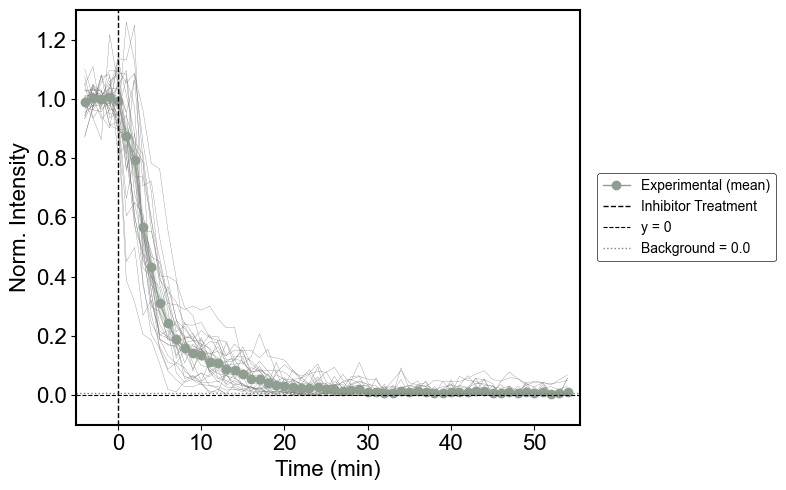

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [6]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_HA'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                # np.ndarray – time array
    intensities_pRS027_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS027_HA, # list – which cells to include
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=True,               # bool – gray individual traces
    figsize = (6, 5),
    ylims = (-0.1, 1.3),
    xlims = (-5, 55.5)    ,                          # limits needs to be set to include more than the fit_end_idx frames for the x-axis
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='None',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
    show_fit=False,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors='#8E9E8F',
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))

## Multi-Reporter Comparison
___

fit_inhibitor_model: unknown model "none". Choose from: linear, exponential, heaviside.
fit_inhibitor_model: unknown model "none". Choose from: linear, exponential, heaviside.
fit_inhibitor_model: unknown model "none". Choose from: linear, exponential, heaviside.


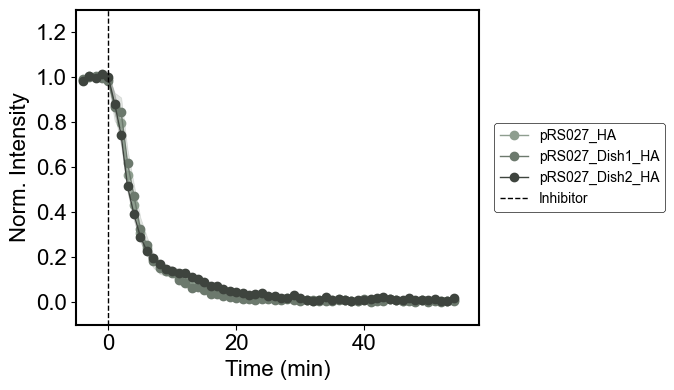

[None, None, None]

In [7]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS027_Dish1_HA, frames_pRS027_Dish2_HA],
    [intensities_pRS027_HA, intensities_pRS027_Dish1_HA, intensities_pRS027_Dish2_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS027_Dish1_HA, responding_indices_pRS027_Dish2_HA],
    colors=['#8E9E8F', "#6C796D", "#3E443E"],
    legend_labels=['pRS027_HA', 'pRS027_Dish1_HA', 'pRS027_Dish2_HA'],
    plot_name='HT_multi',
    #threshold_percentage_for_runoff=-0.4,
    ylims=ylims,
    xlims=(-5, 58),
    figsize=(7, 4),
    use_sem=True,
    show_individual_trajectories=show_individual_trajectories,
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='None',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=fit_end_idx,                         # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=False,                           # bool – draw t½ and τ_runoff lines
    results_folder=results_folder,
)
